In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib import pylab
from PIL import Image
from math import e
import astropy.io.fits as pf
from astropy.io import fits
from scipy import signal

In [266]:
CGPS = fits.open('/home/aordog/DATA/CGPS_FITS_files/CGPS_C21.fits')
hdr = CGPS[0].header
data = CGPS[0].data[0,0]
print(data.shape)
print(hdr['CDELT1'])

CGPS2 = fits.open('/home/aordog/DATA/CGPS_FITS_files/all_stokesi_allbands9.fits')
hdr2 = CGPS2[0].header
data2 = CGPS2[0].data#[0,0]
print(data2.shape)
print(hdr2['CDELT1'])

(4224, 28247)
-0.0049999994
(1825, 29025)
-0.0049999994


In [128]:
def gf(mu,fwhm,x):
    return np.exp(-4*np.log(2)*((x-mu)**2)/fwhm**2)
    

def regular_image(data,j0,i0,nxy,taper=False,taper_width=50,*args,**kwargs):

    image = data[j0:j0+nxy,i0:i0+nxy]

    dxy = np.round(hdr['CDELT2'],5)
    pix0 = int((nxy-1)/2)
    widxy = nxy*dxy
    
    if taper:      
        x, y = np.meshgrid(np.linspace(-(nxy-1)/2,(nxy-1)/2,nxy), 
                       np.linspace(-(nxy-1)/2,(nxy-1)/2,nxy))
        r = np.sqrt(x**2+y**2)
        
        taper = gf(nxy/2-taper_width,taper_width,r)
        taper[np.where(r<=nxy/2-taper_width)] = 1
        image = image*taper

    fig,ax = plt.subplots(1,1,figsize=(6,6)) 
    ax.imshow(image,origin='lower',vmin=0,vmax=30)
    print('Width of each pixel: '+str(dxy)+ ' deg.')
    print('Number of x and y pixels: '+str(nxy))
    print('Central pixel index: '+str(pix0))
    print('Width of image: '+str(widxy)+' deg.')
    
    return image,dxy,pix0,widxy


def padded_image(data,j0,i0,nxy,taper=False,taper_width=50,*args,**kwargs):

    image_small = data[j0:j0+nxy,i0:i0+nxy]

    dxy = np.round(hdr['CDELT2'],5)
    pix0 = int((nxy-1)/2)+int((nxy+1)/2)
    widxy = nxy*dxy
    
    if taper:      
        x, y = np.meshgrid(np.linspace(-(nxy-1)/2,(nxy-1)/2,nxy), 
                       np.linspace(-(nxy-1)/2,(nxy-1)/2,nxy))
        r = np.sqrt(x**2+y**2)
        
        taper = gf(nxy/2-taper_width,taper_width,r)
        taper[np.where(r<=nxy/2-taper_width)] = 1
        image_small = image_small*taper
        plt.plot(taper[511,:])
        
    image = np.zeros([2*nxy+1,2*nxy+1])
    image[:,:] = np.nanmean(image_small)
    image[int((nxy+1)/2):int((nxy+1)/2)+nxy,int((nxy+1)/2):int((nxy+1)/2)+nxy] = image_small

    fig,ax = plt.subplots(1,1,figsize=(6,6)) 
    ax.imshow(image,origin='lower',vmin=0,vmax=30)
    print('Width of each pixel: '+str(dxy)+ ' deg.')
    print('Number of x and y pixels: '+str(nxy))
    print('Central pixel index: '+str(pix0))
    print('Width of image: '+str(widxy)+' deg.')
    
    return image,dxy,pix0,widxy

In [115]:
def taper_func(start,end,x,y,functype='sin',*args,**kwargs):
    
    r = np.sqrt(x**2+y**2)
    
    if ((functype == 'sin') or (functype=='hanning')):
        print(functype)
        
        if functype == 'sin':
        
            b = np.pi/(end-start)
            r0 = (end+start)/2.
            taper = -0.5*np.sin(b*(r - r0))+0.5
            taper[r < start] = 1
            
        if functype == 'hanning':
            
            taper = np.hanning(1023)
            
    else:
        print('bad')
        taper = None
        
    return taper

(350.0, 600.0)

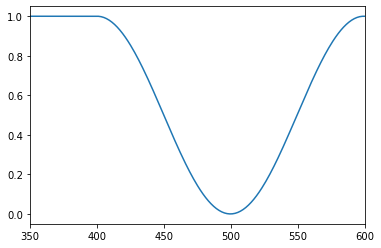

In [126]:
this = np.ones(1023)
that = np.hanning(200)
this[400:600] = 1-that
plt.plot(this)
plt.xlim(350,600)

hanning


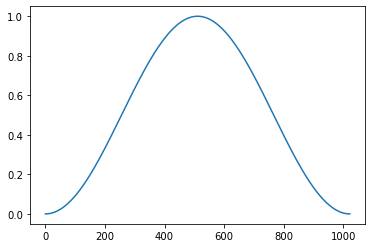

In [117]:
taper = taper_func(200,511,x,y,functype='hanning')
plt.plot(taper)

sin
arctan


(0.99, 1.0)

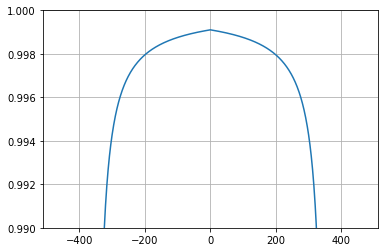

In [106]:
nxy = 1023

x, y = np.meshgrid(np.linspace(-(nxy-1)/2,(nxy-1)/2,nxy), 
                       np.linspace(-(nxy-1)/2,(nxy-1)/2,nxy))

taper1 = taper_func(300,511,x,y)
taper2 = taper_func(200,511,x,y,functype='arctan')

idx0 = int(x.shape[0]/2)
#plt.plot(x[idx0,:],taper1[idx0,:])
plt.plot(x[idx0,:],taper2[idx0,:])
plt.xlim(x[idx0,0],x[idx0,-1])
plt.grid()
plt.ylim(0.99,1)

Width of each pixel: 0.005 deg.
Number of x and y pixels: 1023
Central pixel index: 511
Width of image: 5.115 deg.


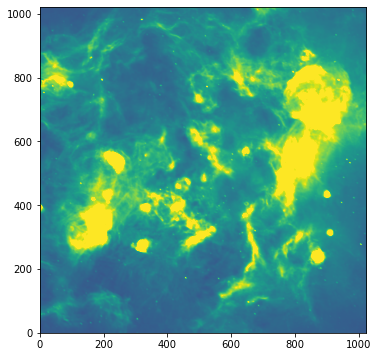

In [147]:
j0 = 400
i0 = 22100

image,dxy,pix0,widxy = regular_image(data,j0,i0,1023)
#image,dxy,pix0,widxy = padded_image(data,j0,i0,1023,taper=False,taper_width=100)


[-384.92926651 -384.17598027 -383.42269404 ...  383.42269404  384.17598027
  384.92926651]


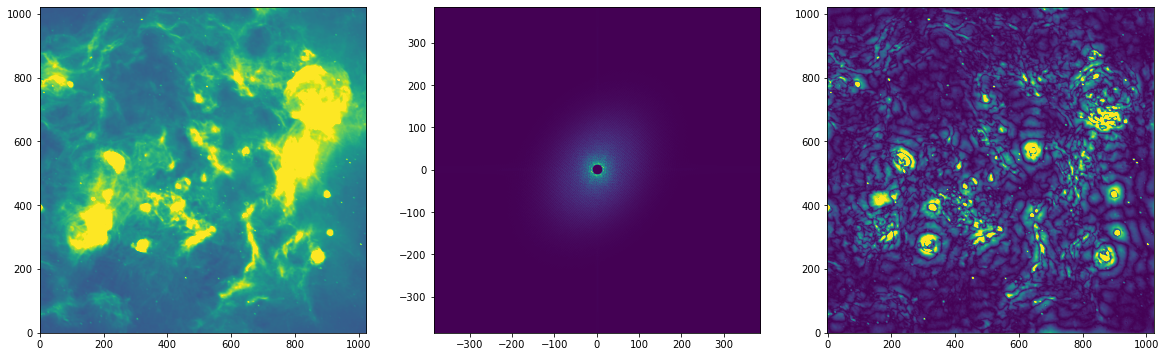

In [131]:
image_FFT = np.fft.fft2(image)
image_FFT_shift = np.fft.fftshift(image_FFT)

uv_freq = np.fft.fftshift(np.fft.fftfreq(image.shape[0]))/dxy
uv_m = uv_freq*(3e8/1420e6)*180/(np.pi**2)
print(uv_m) # Units of 1/deg

xuv, yuv = np.meshgrid(uv_m, uv_m)
ruv = np.sqrt(xuv**2+yuv**2)

#print(x)
#print(y)

r1 = 12
r2 = 12
#### Low-pass:
#w = np.where(ruv > r1)
#### High-pass:
w = np.where(ruv < r2)
#### Missing baselines:
#w = np.where((ruv > r1) & (ruv < r2))

image_FFT_shift[w]=0
image_IFFT = np.fft.ifft2(np.fft.ifftshift(image_FFT_shift))

#HighPass = np.fft.ifftshift(HighPassCenter)

dpix = 100

fig,ax = plt.subplots(1,3,figsize=(20,6)) 
ax[0].imshow(image,origin='lower',vmin=0,vmax=30)
ax[1].imshow(abs(image_FFT_shift),origin='lower',vmin=0,vmax=1e5,extent=[uv_m[0],uv_m[-1],uv_m[0],uv_m[-1]])
ax[2].imshow(abs(image_IFFT),origin='lower',vmin=0,vmax=10)
ax[1].set_xlim(uv_m[0],uv_m[-1])
ax[1].set_ylim(uv_m[0],uv_m[-1])
#ax[3].imshow(image-abs(image_IFFT),origin='lower',vmin=-20,vmax=20)


plt.show()


[-384.92926651 -384.17598027 -383.42269404 ...  383.42269404  384.17598027
  384.92926651]
(1023, 1023)
10 21


(-384.9292665078778, 384.9292665078778)

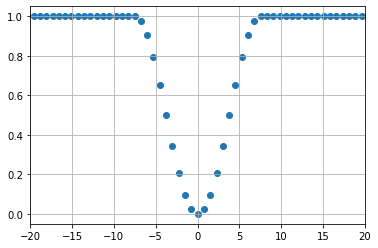

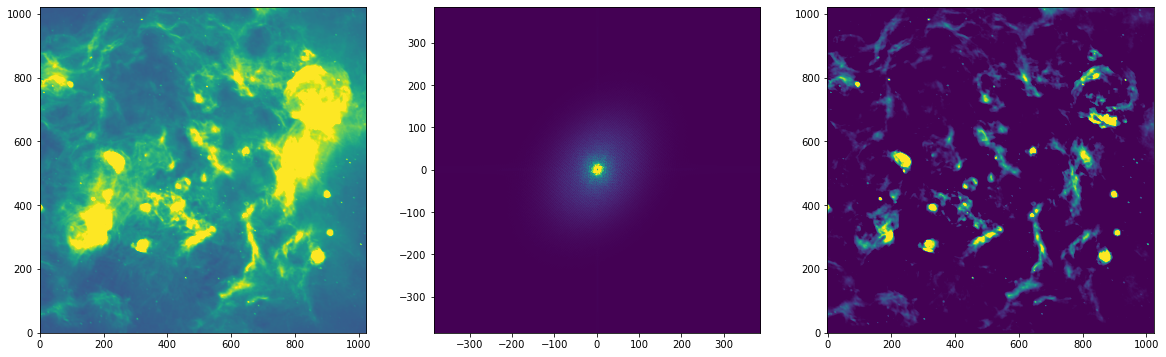

In [264]:
image_FFT = np.fft.fft2(image)
image_FFT_shift = np.fft.fftshift(image_FFT)

uv_freq = np.fft.fftshift(np.fft.fftfreq(image.shape[0]))/dxy
uv_m = uv_freq*(3e8/1420e6)*180/(np.pi**2)
print(uv_m) # Units of 1/deg

xuv, yuv = np.meshgrid(uv_m, uv_m)
ruv = np.sqrt(xuv**2+yuv**2)

r1 = 6
r2 = 12
mask = np.ones_like(image)
print(mask.shape)
npix1 = 2*int(np.round(r1*np.diff(uv_m)[0],0))
npix = npix1*2+1
print(npix1,npix)
window1d = np.hanning(npix)
window2d = 1-np.outer(window1d,window1d)

mask[pix0-npix1:pix0+npix1+1,pix0-npix1:pix0+npix1+1] = window2d

plt.scatter(xuv[pix0,:],mask[pix0,:])
plt.grid()
plt.xlim(-20,20)

#mask = gf(r1,15,ruv)
#mask[ruv > r1] = 1
#plt.plot(uv_m,mask[pix0,:])
#plt.xlim(-30,30)
#plt.grid()

#image_FFT_shift[w]=0
image_FFT_shift = image_FFT_shift*mask
image_IFFT = np.fft.ifft2(np.fft.ifftshift(image_FFT_shift))

dpix = 100

#plt.plot(image_IFFT[511,:].real)

fig,ax = plt.subplots(1,3,figsize=(20,6)) 
ax[0].imshow(image,origin='lower',vmin=0,vmax=30)
ax[1].imshow(abs(image_FFT_shift),origin='lower',vmin=0,vmax=1e5,extent=[uv_m[0],uv_m[-1],uv_m[0],uv_m[-1]])
ax[2].imshow(image_IFFT.real,origin='lower',vmin=0,vmax=20)
ax[1].set_xlim(uv_m[0],uv_m[-1])
ax[1].set_ylim(uv_m[0],uv_m[-1])



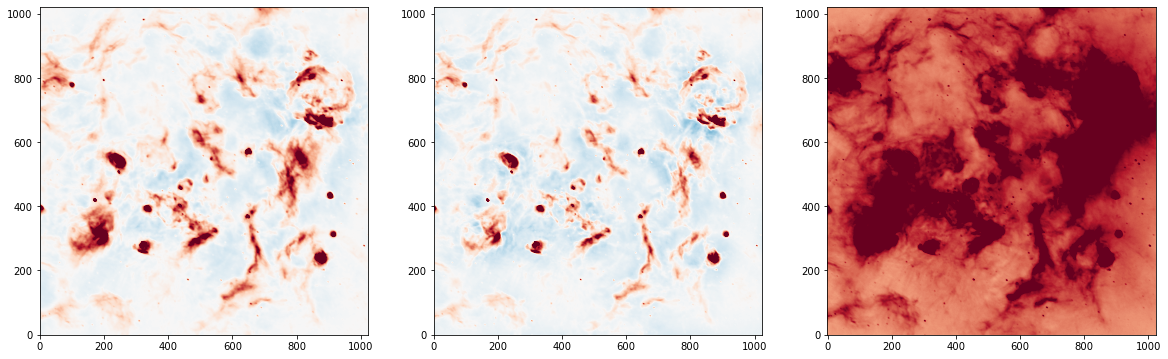

In [265]:
fig,ax = plt.subplots(1,3,figsize=(20,10)) 
ax[0].imshow(image2,origin='lower',vmin=-0.2,vmax=0.2,cmap='RdBu_r')
ax[1].imshow(image_IFFT.real,origin='lower',vmin=-25,vmax=25,cmap='RdBu_r')
ax[2].imshow(image,origin='lower',vmin=-20,vmax=20,cmap='RdBu_r')

(491.0, 531.0)

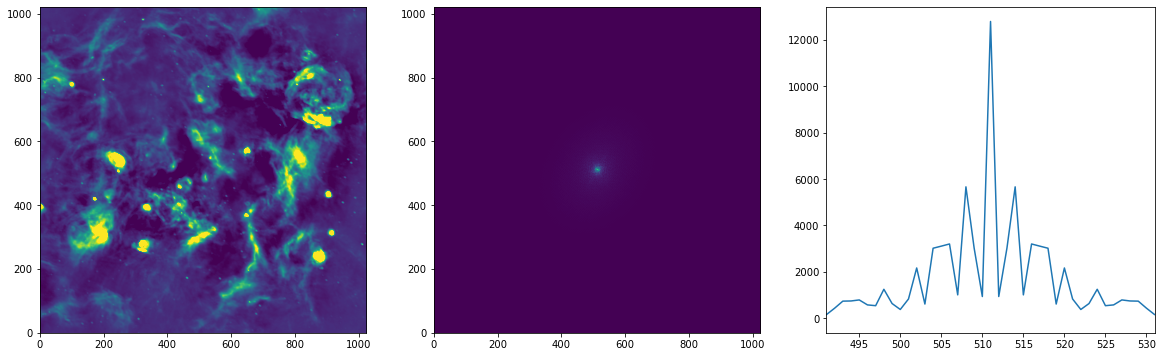

In [172]:
j0 = 400
i0 = 22555
taper_width = 50
nxy = 1023

image2 = data2[j0:j0+nxy,i0:i0+nxy]

image_FFT2 = np.fft.fft2(image2)
image_FFT_shift2 = np.fft.fftshift(image_FFT2)
image_IFFT2 = np.fft.ifft2(image_FFT_shift2)


dpix = 100

fig,ax = plt.subplots(1,3,figsize=(20,6)) 
ax[0].imshow(image2,origin='lower',vmin=-0.03,vmax=0.2)
ax[1].imshow(abs(image_FFT_shift2),origin='lower',vmin=0,vmax=5e3)
ax[2].plot(abs(image_FFT_shift2[511,:]))
ax[2].set_xlim(511-20,511+20)

In [ ]:
plt.plot(abs(image_IFFT[511,:]))
#plt.plot(abs(image2[511,:])*70)

In [ ]:
print(image.shape[0])

In [ ]:
0.5/0.005

In [ ]:
lbd = 3e8/448.4e6
print(lbd)

In [ ]:
D = 66

this = (np.pi**2)*D/(180*lbd)
print(this)